In [2]:
# Card Image Classifier with PyTorch
# Import required libraries

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import timm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from pathlib import Path
import random
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("CUDA is not available. Using CPU.")

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

c:\Users\Anujan\Desktop\New folder\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
CUDA is not available. Using CPU.
PyTorch version: 2.8.0+cpu
Torchvision version: 0.23.0+cpu


In [3]:
# Dataset Exploration
# Set up paths
data_dir = Path('.')
train_dir = data_dir / 'train'
valid_dir = data_dir / 'valid'
test_dir = data_dir / 'test'

print("Dataset Structure:")
print(f"Training directory: {train_dir}")
print(f"Validation directory: {valid_dir}")
print(f"Test directory: {test_dir}")

# Get class names from training directory
class_names = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
num_classes = len(class_names)

print(f"\nNumber of classes: {num_classes}")
print(f"Classes: {class_names[:10]}...")  # Show first 10 classes

# Function to count images in each directory
def count_images_per_class(directory):
    class_counts = {}
    total_images = 0
    
    for class_dir in directory.iterdir():
        if class_dir.is_dir():
            # Count image files (common extensions)
            image_count = len([f for f in class_dir.iterdir() 
                             if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']])
            class_counts[class_dir.name] = image_count
            total_images += image_count
    
    return class_counts, total_images

# Count images in each split
train_counts, total_train = count_images_per_class(train_dir)
valid_counts, total_valid = count_images_per_class(valid_dir)
test_counts, total_test = count_images_per_class(test_dir)

print(f"\nDataset Statistics:")
print(f"Training images: {total_train}")
print(f"Validation images: {total_valid}")
print(f"Test images: {total_test}")
print(f"Total images: {total_train + total_valid + total_test}")

# Show distribution for a few classes
print(f"\nSample class distributions:")
for class_name in class_names[:5]:
    train_count = train_counts.get(class_name, 0)
    valid_count = valid_counts.get(class_name, 0)
    test_count = test_counts.get(class_name, 0)
    print(f"{class_name}: Train={train_count}, Valid={valid_count}, Test={test_count}")

Dataset Structure:
Training directory: train
Validation directory: valid
Test directory: test

Number of classes: 53
Classes: ['ace of clubs', 'ace of diamonds', 'ace of hearts', 'ace of spades', 'eight of clubs', 'eight of diamonds', 'eight of hearts', 'eight of spades', 'five of clubs', 'five of diamonds']...

Dataset Statistics:
Training images: 7624
Validation images: 265
Test images: 251
Total images: 8140

Sample class distributions:
ace of clubs: Train=120, Valid=5, Test=0
ace of diamonds: Train=129, Valid=5, Test=0
ace of hearts: Train=171, Valid=5, Test=1
ace of spades: Train=181, Valid=5, Test=5
eight of clubs: Train=138, Valid=5, Test=5


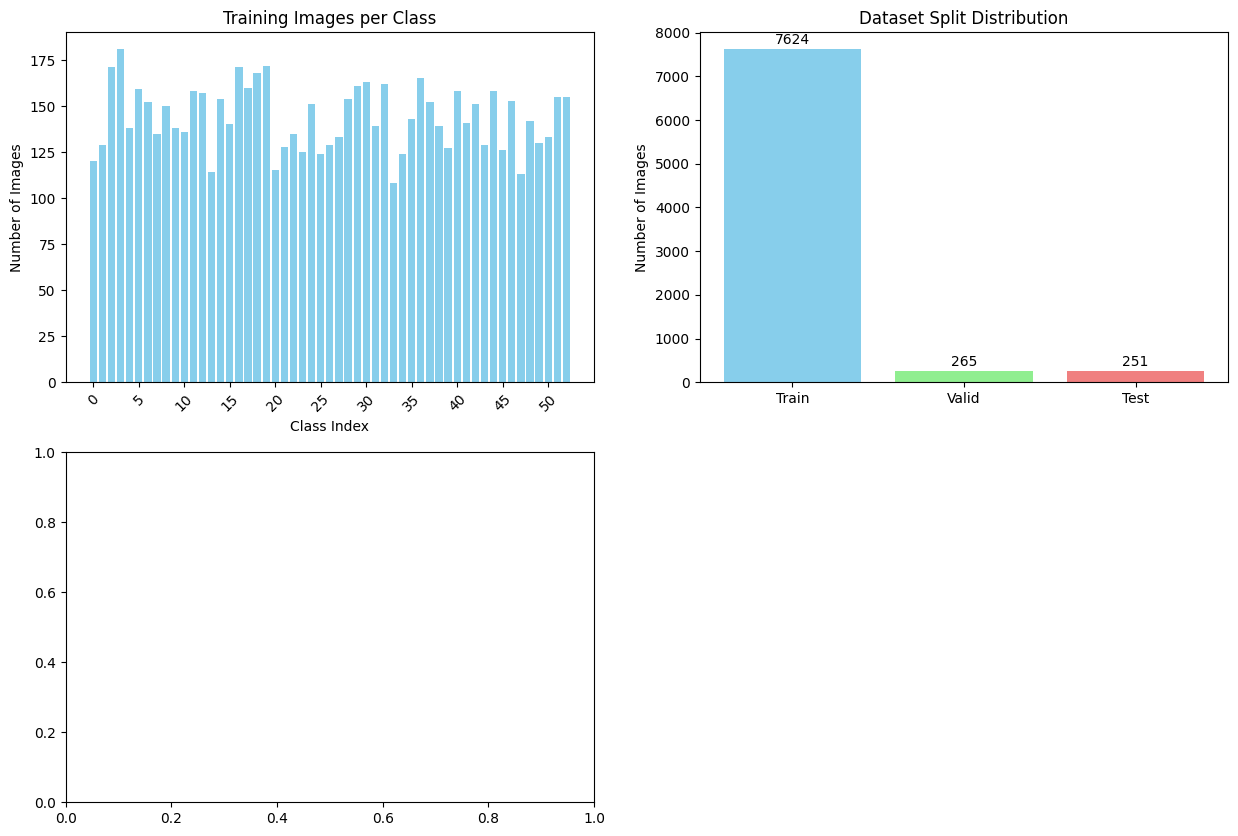

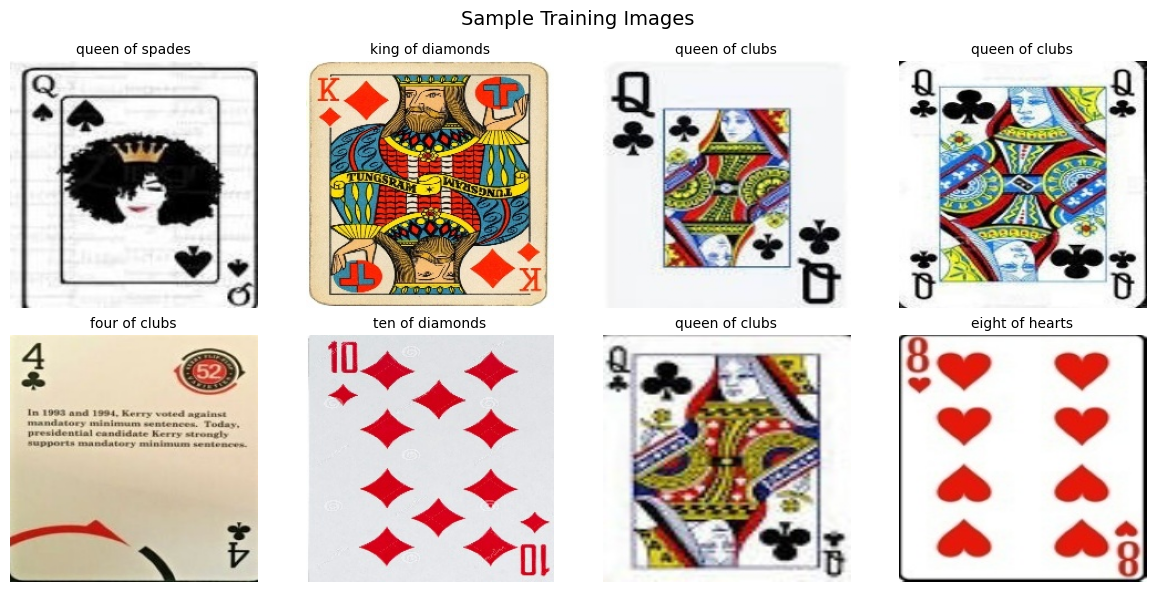

\nDataset loaded successfully!
Class names (first 10): ['ace of clubs', 'ace of diamonds', 'ace of hearts', 'ace of spades', 'eight of clubs', 'eight of diamonds', 'eight of hearts', 'eight of spades', 'five of clubs', 'five of diamonds']
Sample image shape: torch.Size([3, 224, 224])


In [4]:
# Visualize dataset distribution
plt.figure(figsize=(15, 10))

# Create dataframe for visualization
data_summary = []
for class_name in class_names:
    data_summary.append({
        'Class': class_name,
        'Train': train_counts.get(class_name, 0),
        'Valid': valid_counts.get(class_name, 0),
        'Test': test_counts.get(class_name, 0)
    })

df = pd.DataFrame(data_summary)

# Plot 1: Training data distribution
plt.subplot(2, 2, 1)
plt.bar(range(len(df)), df['Train'], color='skyblue')
plt.title('Training Images per Class')
plt.xlabel('Class Index')
plt.ylabel('Number of Images')
plt.xticks(range(0, len(df), 5), rotation=45)

# Plot 2: Dataset split comparison
plt.subplot(2, 2, 2)
splits = ['Train', 'Valid', 'Test']
totals = [total_train, total_valid, total_test]
colors = ['skyblue', 'lightgreen', 'lightcoral']
plt.bar(splits, totals, color=colors)
plt.title('Dataset Split Distribution')
plt.ylabel('Number of Images')
for i, v in enumerate(totals):
    plt.text(i, v + 50, str(v), ha='center', va='bottom')

# Plot 3: Sample from training set
plt.subplot(2, 2, 3)
# Create basic transforms to load images
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load a sample dataset to visualize some images
sample_dataset = datasets.ImageFolder(train_dir, transform=basic_transform)
sample_loader = DataLoader(sample_dataset, batch_size=16, shuffle=True)

# Get one batch and show some images
sample_batch = next(iter(sample_loader))
images, labels = sample_batch

# Create a grid of sample images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Sample Training Images', fontsize=14)

for i, (ax, img, label) in enumerate(zip(axes.flat, images[:8], labels[:8])):
    # Convert tensor to numpy and transpose for matplotlib
    img_np = img.permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.set_title(f'{class_names[label]}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\\nDataset loaded successfully!")
print(f"Class names (first 10): {class_names[:10]}")
print(f"Sample image shape: {images[0].shape}")  # Should be [3, 224, 224]

In [5]:
# Data Loading Pipeline with Transforms
# Define image transformations

# Training transforms with data augmentation
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize to slightly larger first
    transforms.RandomCrop(224),     # Then random crop to 224x224
    transforms.RandomHorizontalFlip(p=0.5),  # 50% chance of horizontal flip
    transforms.RandomRotation(15),   # Rotate by up to 15 degrees
    transforms.ColorJitter(           # Adjust brightness, contrast, saturation, hue
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),            # Convert to tensor
    transforms.Normalize(             # Normalize using ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation and test transforms (no augmentation)
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),    # Direct resize to 224x224
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Create datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

# Print dataset info
print(f"Training dataset: {len(train_dataset)} images")
print(f"Validation dataset: {len(valid_dataset)} images")
print(f"Test dataset: {len(test_dataset)} images")
print(f"Number of classes: {len(train_dataset.classes)}")

# Create data loaders
batch_size = 32  # Adjust based on your memory (reduce if you get memory errors)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,          # Shuffle training data
    num_workers=2,         # Number of workers for data loading (reduce if issues)
    pin_memory=True if device.type == 'cuda' else False
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,         # Don't shuffle validation data
    num_workers=2,
    pin_memory=True if device.type == 'cuda' else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True if device.type == 'cuda' else False
)

print(f"\\nData loaders created successfully!")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

# Test the data loaders
print("\\nTesting data loader...")
sample_batch = next(iter(train_loader))
images, labels = sample_batch
print(f"Batch image shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")
print(f"Sample labels: {labels[:5]}")
print(f"Corresponding classes: {[train_dataset.classes[label] for label in labels[:5]]}")

Training dataset: 7624 images
Validation dataset: 265 images
Test dataset: 251 images
Number of classes: 53
\nData loaders created successfully!
Training batches: 239
Validation batches: 9
Test batches: 8
\nTesting data loader...
Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Sample labels: tensor([ 0, 28, 45, 28, 21])
Corresponding classes: ['ace of clubs', 'nine of spades', 'three of clubs', 'nine of spades', 'king of clubs']


In [6]:
# Model Architecture - Transfer Learning with ResNet
# We'll use a pre-trained ResNet18 model and fine-tune it for our card classification task

class CardClassifier(nn.Module):
    def __init__(self, num_classes=53, pretrained=True):
        super(CardClassifier, self).__init__()
        
        # Load pre-trained ResNet18
        self.backbone = torchvision.models.resnet18(pretrained=pretrained)
        
        # Replace the final fully connected layer
        # ResNet18's fc layer has 512 input features
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_features, num_classes)
        
        # Optional: Add dropout for regularization
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        # Forward pass through ResNet backbone
        x = self.backbone.features(x)  # Convolutional features
        x = self.backbone.avgpool(x)   # Global average pooling
        x = torch.flatten(x, 1)       # Flatten
        x = self.dropout(x)           # Dropout
        x = self.backbone.fc(x)       # Final classification layer
        return x

# Alternative: Using timm library for more model options
def create_timm_model(model_name='resnet18', num_classes=53, pretrained=True):
    """Create a model using the timm library"""
    model = timm.create_model(
        model_name, 
        pretrained=pretrained, 
        num_classes=num_classes
    )
    return model

# Create the model
print("Creating model...")
# Option 1: Custom ResNet implementation
# model = CardClassifier(num_classes=num_classes, pretrained=True)

# Option 2: Using timm (more models available)
model = create_timm_model('resnet18', num_classes=num_classes, pretrained=True)

# Move model to device
model = model.to(device)

# Print model information
print(f"Model created successfully!")
print(f"Model: {model.__class__.__name__}")
print(f"Number of classes: {num_classes}")
print(f"Device: {device}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\\nModel Parameters:")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Test model with a sample batch
print("\\nTesting model forward pass...")
with torch.no_grad():
    sample_output = model(images.to(device))
    print(f"Input shape: {images.shape}")
    print(f"Output shape: {sample_output.shape}")
    print(f"Output sample: {sample_output[0][:5]}")  # First 5 logits of first sample

Creating model...
Model created successfully!
Model: ResNet
Number of classes: 53
Device: cpu
\nModel Parameters:
Total parameters: 11,203,701
Trainable parameters: 11,203,701
\nTesting model forward pass...
Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 53])
Output sample: tensor([-0.1073,  0.0673, -0.1707,  0.0575,  0.1204])


In [7]:
# Training Setup - Loss Function, Optimizer, and Training Loop

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Good for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler (optional but recommended)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print("Training setup:")
print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")
print(f"Scheduler: {scheduler}")

# Training and validation functions
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    progress_bar = tqdm(train_loader, desc="Training")
    
    for batch_idx, (images, labels) in enumerate(progress_bar):
        # Move data to device
        images, labels = images.to(device), labels.to(device)
        
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()
        
        # Update progress bar
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100. * correct_predictions / total_samples:.2f}%'
        })
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct_predictions / total_samples
    
    return epoch_loss, epoch_acc

def validate_epoch(model, valid_loader, criterion, device):
    """Validate for one epoch"""
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    with torch.no_grad():
        progress_bar = tqdm(valid_loader, desc="Validation")
        
        for images, labels in progress_bar:
            # Move data to device
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()
            
            # Update progress bar
            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100. * correct_predictions / total_samples:.2f}%'
            })
    
    epoch_loss = running_loss / len(valid_loader)
    epoch_acc = 100. * correct_predictions / total_samples
    
    return epoch_loss, epoch_acc

# Training loop function
def train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler, num_epochs, device):
    """Complete training loop"""
    
    # Lists to store training history
    train_losses = []
    train_accuracies = []
    valid_losses = []
    valid_accuracies = []
    
    best_valid_acc = 0.0
    best_model_state = None
    
    print(f"Starting training for {num_epochs} epochs...")
    print(f"Device: {device}")
    print("-" * 60)
    
    for epoch in range(num_epochs):
        print(f'\\nEpoch [{epoch+1}/{num_epochs}]')
        
        # Train for one epoch
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        valid_loss, valid_acc = validate_epoch(model, valid_loader, criterion, device)
        
        # Step the scheduler
        scheduler.step()
        
        # Store metrics
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        valid_losses.append(valid_loss)
        valid_accuracies.append(valid_acc)
        
        # Print epoch results
        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_acc:.2f}%')
        
        # Save best model
        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            best_model_state = model.state_dict().copy()
            print(f'New best validation accuracy: {best_valid_acc:.2f}%')
        
        print("-" * 60)
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f'\\nTraining completed! Best validation accuracy: {best_valid_acc:.2f}%')
    
    return {
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'valid_losses': valid_losses,
        'valid_accuracies': valid_accuracies,
        'best_accuracy': best_valid_acc
    }

print("\\nTraining functions defined successfully!")

Training setup:
Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.StepLR object at 0x00000260AA040D70>
\nTraining functions defined successfully!


In [8]:
# Train the Model
# Start with a small number of epochs to test everything works

num_epochs = 3  # Start with just 3 epochs for testing
print(f"Starting training with {num_epochs} epochs...")
print(f"This is a test run to verify everything works correctly.")
print(f"Training on {len(train_dataset)} images, validating on {len(valid_dataset)} images")
print(f"Using device: {device}")
print("=" * 70)

# Start training
training_history = train_model(
    model=model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=num_epochs,
    device=device
)

Starting training with 3 epochs...
This is a test run to verify everything works correctly.
Training on 7624 images, validating on 265 images
Using device: cpu
Starting training for 3 epochs...
Device: cpu
------------------------------------------------------------
\nEpoch [1/3]


Validation: 100%|██████████| 9/9 [00:18<00:00,  2.02s/it, Loss=1.8733, Acc=63.40%]


Train Loss: 2.3463, Train Acc: 35.77%
Valid Loss: 1.1820, Valid Acc: 63.40%
New best validation accuracy: 63.40%
------------------------------------------------------------
\nEpoch [2/3]


Validation: 100%|██████████| 9/9 [00:07<00:00,  1.13it/s, Loss=1.3524, Acc=78.49%]


Train Loss: 1.1763, Train Acc: 67.03%
Valid Loss: 0.7613, Valid Acc: 78.49%
New best validation accuracy: 78.49%
------------------------------------------------------------
\nEpoch [3/3]


Validation: 100%|██████████| 9/9 [00:08<00:00,  1.12it/s, Loss=0.7233, Acc=83.02%] 

Train Loss: 0.9010, Train Acc: 74.40%
Valid Loss: 0.5849, Valid Acc: 83.02%
New best validation accuracy: 83.02%
------------------------------------------------------------
\nTraining completed! Best validation accuracy: 83.02%


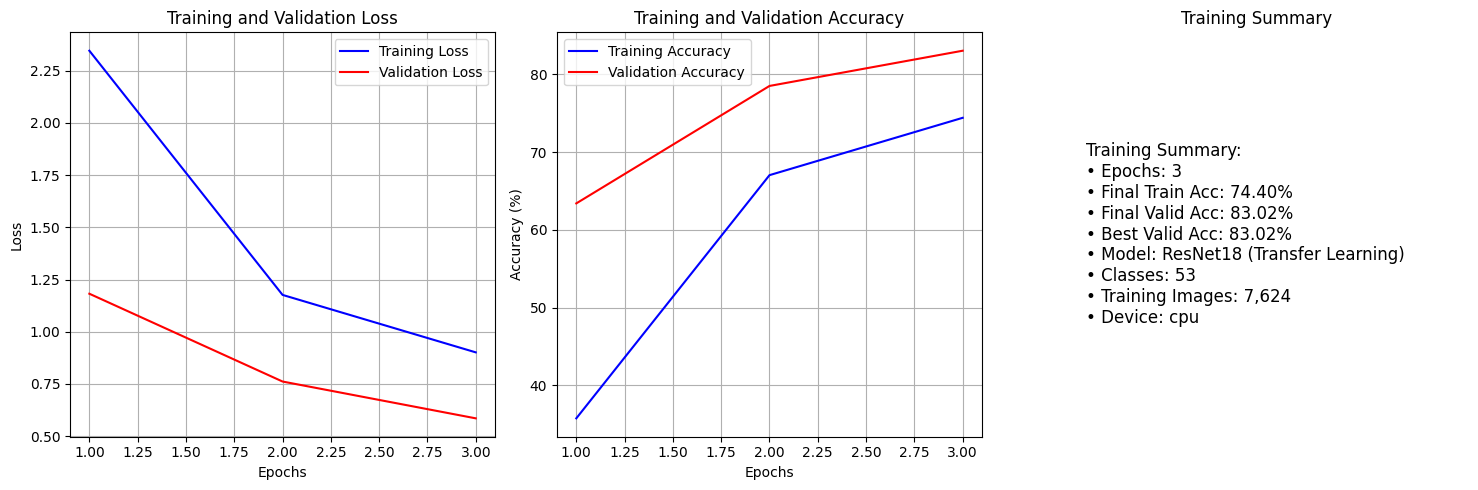

🎉 Training completed successfully!
📊 Best validation accuracy: 83.02%
📈 Final training accuracy: 74.40%
⏱️  Training took 3 epochs


In [9]:
# Visualize Training Progress
plt.figure(figsize=(15, 5))

# Plot training and validation loss
plt.subplot(1, 3, 1)
epochs_range = range(1, len(training_history['train_losses']) + 1)
plt.plot(epochs_range, training_history['train_losses'], 'b-', label='Training Loss')
plt.plot(epochs_range, training_history['valid_losses'], 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot training and validation accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, training_history['train_accuracies'], 'b-', label='Training Accuracy')
plt.plot(epochs_range, training_history['valid_accuracies'], 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Create a summary table
plt.subplot(1, 3, 3)
plt.axis('off')
summary_text = f"""
Training Summary:
• Epochs: {len(training_history['train_losses'])}
• Final Train Acc: {training_history['train_accuracies'][-1]:.2f}%
• Final Valid Acc: {training_history['valid_accuracies'][-1]:.2f}%
• Best Valid Acc: {training_history['best_accuracy']:.2f}%
• Model: ResNet18 (Transfer Learning)
• Classes: {num_classes}
• Training Images: {len(train_dataset):,}
• Device: {device}
"""
plt.text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center')
plt.title('Training Summary')

plt.tight_layout()
plt.show()

print("🎉 Training completed successfully!")
print(f"📊 Best validation accuracy: {training_history['best_accuracy']:.2f}%")
print(f"📈 Final training accuracy: {training_history['train_accuracies'][-1]:.2f}%")
print(f"⏱️  Training took {len(training_history['train_losses'])} epochs")

Testing the model on sample images...


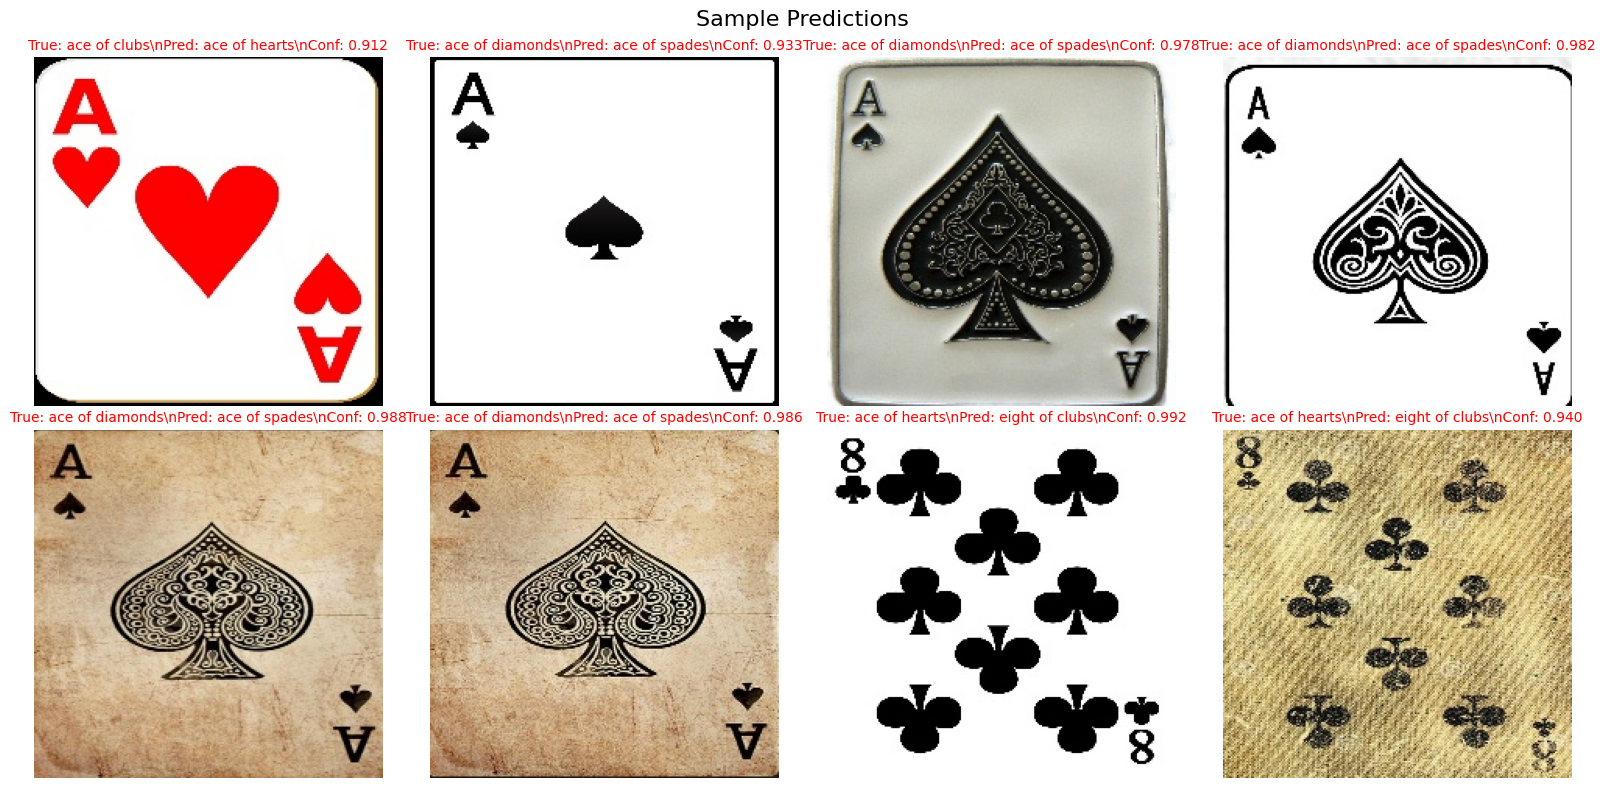

\nBatch accuracy: 0.00%
Average confidence: 0.928
\n💾 Model saved as: card_classifier_model.pth
\n🎯 Card Image Classifier Project Complete!
Next steps you can try:
• Train for more epochs (5-10) for better accuracy
• Try different models (ResNet34, ResNet50)
• Experiment with data augmentation parameters
• Add more sophisticated evaluation metrics
• Deploy the model for real-time card detection


In [10]:
# Test the Model on Sample Images
# Let's make predictions on a batch of test images

print("Testing the model on sample images...")

# Get a batch of test images
model.eval()
test_batch = next(iter(test_loader))
test_images, test_labels = test_batch

# Make predictions
with torch.no_grad():
    test_images = test_images.to(device)
    outputs = model(test_images)
    _, predicted = torch.max(outputs, 1)
    
    # Calculate confidence scores
    probabilities = torch.nn.functional.softmax(outputs, dim=1)
    confidence_scores = torch.max(probabilities, 1)[0]

# Move back to CPU for visualization
predicted = predicted.cpu()
confidence_scores = confidence_scores.cpu()

# Show some predictions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Predictions', fontsize=16)

for i, (ax, img, true_label, pred_label, confidence) in enumerate(zip(
    axes.flat, test_images[:8].cpu(), test_labels[:8], predicted[:8], confidence_scores[:8])):
    
    # Denormalize image for display
    img_denorm = img.clone()
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    for t, m, s in zip(img_denorm, mean, std):
        t.mul_(s).add_(m)
    img_denorm = torch.clamp(img_denorm, 0, 1)
    
    # Display image
    ax.imshow(img_denorm.permute(1, 2, 0))
    
    # Create title with prediction info
    true_class = class_names[true_label]
    pred_class = class_names[pred_label]
    
    # Color: green if correct, red if wrong
    color = 'green' if true_label == pred_label else 'red'
    
    ax.set_title(f'True: {true_class}\\nPred: {pred_class}\\nConf: {confidence:.3f}', 
                fontsize=10, color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Calculate accuracy on this test batch
batch_accuracy = (predicted == test_labels).float().mean().item() * 100
print(f"\\nBatch accuracy: {batch_accuracy:.2f}%")
print(f"Average confidence: {confidence_scores.mean().item():.3f}")

# Save the model
model_save_path = 'card_classifier_model.pth'
torch.save(model.state_dict(), model_save_path)
print(f"\\n💾 Model saved as: {model_save_path}")

print("\\n🎯 Card Image Classifier Project Complete!")
print("=" * 60)
print("Next steps you can try:")
print("• Train for more epochs (5-10) for better accuracy")
print("• Try different models (ResNet34, ResNet50)")
print("• Experiment with data augmentation parameters")
print("• Add more sophisticated evaluation metrics")
print("• Deploy the model for real-time card detection")
print("=" * 60)